In [281]:
import pandas as pd

df = pd.read_csv("listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN
3,821213014263313420,https://www.airbnb.com/rooms/821213014263313420,20250926170004,2025-09-27,previous scrape,Amazing en suite bedroom Leblon,"Kick back and relax in this calm, stylish spac...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,449763717,...,5.00,5.00,4.67,NaN,f,2,1,1,0,0.10
4,821223043903573522,https://www.airbnb.com/rooms/821223043903573522,20250926170004,2025-09-27,city scrape,Incrível apartamento frente mar,Amazing 1-bedroom apartment facing the sea. Co...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25961210,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.60


In [282]:
cidade = "Rio de Janeiro"
print(f"Cidade analisada: {cidade}")

Cidade analisada: Rio de Janeiro


In [283]:
#colunas, linhas
df.shape

(43068, 79)

In [284]:

#colunas
df.columns
#Tipo de dado de cada coluna
df.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

In [285]:
#Ranking dos que possuem mais valores nulos
df.isnull().sum().sort_values(ascending=False)

license                                         43068
calendar_updated                                43068
neighbourhood_group_cleansed                    43068
neighbourhood                                   26738
neighborhood_overview                           26738
                                                ...  
instant_bookable                                    0
calculated_host_listings_count                      0
calculated_host_listings_count_entire_homes         0
calculated_host_listings_count_private_rooms        0
calculated_host_listings_count_shared_rooms         0
Length: 79, dtype: int64

In [286]:
colunas_relevantes = [
    'price',
    'room_type', 
    'neighbourhood_cleansed',
    'accommodates',
    'number_of_reviews', 
    'reviews_per_month',  
    'amenities'                   
]

In [287]:
proxy = 'number_of_reviews'

In [288]:
df[colunas_relevantes].info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   38670 non-null  str    
 1   room_type               43068 non-null  str    
 2   neighbourhood_cleansed  43068 non-null  str    
 3   accommodates            43068 non-null  int64  
 4   number_of_reviews       43068 non-null  int64  
 5   reviews_per_month       33882 non-null  float64
 6   amenities               43068 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 2.3 MB


### Tratamento de PRICE
**Justificativa de Price:** Realizei o tratamento dos dados na coluna PRICE, que possuia caracteres especiais. Os removi e converti a coluna em float para melhorar a ánalise com base nos preços

In [289]:
df['price'].head(10)

0      $580.00
1    $1,900.00
2      $700.00
3          NaN
4      $500.00
5      $461.00
6          NaN
7      $281.00
8      $950.00
9      $450.00
Name: price, dtype: str

In [290]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [291]:
df['price'].head(10)

0     580.0
1    1900.0
2     700.0
3       NaN
4     500.0
5     461.0
6       NaN
7     281.0
8     950.0
9     450.0
Name: price, dtype: float64

In [292]:
df[colunas_relevantes].head(5)

,price,room_type,neighbourhood_cleansed,accommodates,number_of_reviews,reviews_per_month,amenities
0,580.0,Entire home/apt,Leblon,4,86,2.72,"[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,1900.0,Entire home/apt,Copacabana,2,0,NaN,"[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,700.0,Entire home/apt,Pavuna,4,0,NaN,"[""BBQ grill"", ""Exterior security cameras on pr..."
3,NaN,Private room,Leblon,2,3,0.10,"[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,500.0,Entire home/apt,Barra da Tijuca,4,11,0.60,"[""Outdoor shower"", ""Pool"", ""Free parking on pr..."


In [293]:
df['price'].isnull().sum()

np.int64(4398)

In [294]:
df = df.dropna(subset=['price']).copy()

In [295]:
df['price'].isnull().sum()

np.int64(0)

### Transformação de Amenidades
**Justificativa das Amenidades:** Optei por extrair as 5 amenidades mais frequentes na base de dados pois elas representam a infraestrutura básica e o padrão mínimo esperado pela maioria dos hóspedes

In [296]:
# 1. Removemos os colchetes e aspas da string usando regex
amenities_limpas = df['amenities'].str.replace(r'[\[\]"]', '', regex=True)

# 2. Separamos o texto por vírgulas para criar uma lista
amenities_listas = amenities_limpas.str.split(', ')

# 3. O 'explode' separa cada item da lista em uma linha temporária.
ranking_amenidades = amenities_listas.explode().value_counts()

# Mostrando amenidades que mais aparecem no Rio de Janeiro
display(ranking_amenidades.head(5))

amenities
Kitchen                  35206
Wifi                     34973
Hot water                25261
Dishes and silverware    24148
Air conditioning         24106
Name: count, dtype: int64

In [297]:
top_amenidades = ranking_amenidades.head(5).index.tolist()

import re
colunas_novas = []

for amenidade in top_amenidades:
    nome_limpo = re.sub(r'[^a-zA-Z0-9]', '_', amenidade.lower())
    nome_coluna = f'has_{nome_limpo}'
    
    df[nome_coluna] = df['amenities'].str.contains(amenidade, case=False, na=False).astype(int)
    
    colunas_novas.append(nome_coluna)

df[['price', 'accommodates'] + colunas_novas].head(10)    

,price,accommodates,has_kitchen,has_wifi,has_hot_water,has_dishes_and_silverware,has_air_conditioning
0,580.0,4,1,1,1,1,0
1,1900.0,2,1,1,0,0,1
2,700.0,4,1,0,0,0,1
4,500.0,4,1,1,0,0,1
5,461.0,6,1,1,1,1,1
7,281.0,2,1,1,1,1,0
8,950.0,2,1,1,1,1,1
9,450.0,4,0,1,1,0,0
10,1000.0,6,1,1,1,1,1
11,980.0,3,1,1,1,1,1


In [298]:
resumo = df.groupby('room_type').agg({
    'price': ['mean', 'median'],
    'number_of_reviews': 'mean',
    'accommodates': 'mean'
})
print(resumo)

                      price        number_of_reviews accommodates
                       mean median              mean         mean
room_type                                                        
Entire home/apt  800.152831  350.0         29.843272     4.342234
Hotel room       619.800000  470.0         56.400000     2.933333
Private room     375.078981  205.0         17.672709     2.327003
Shared room      199.075949  105.0          9.377215     4.708861


In [299]:
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(5)

neighbourhood_cleansed
Estácio        7003.148649
Joá            6878.132075
São Conrado    3000.919162
Anchieta       2531.000000
Itanhangá      2528.747191
Name: price, dtype: float64

In [300]:
# Preço por pessoa
df['price_per_person'] = df['price'] / df['accommodates']

# Faixa de preço
df['faixa_preco'] = pd.cut(df['price'],
    bins=[0, 150, 400, float('inf')],
    labels=['Barato', 'Médio', 'Caro'])

# Superhost como binário
df['is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

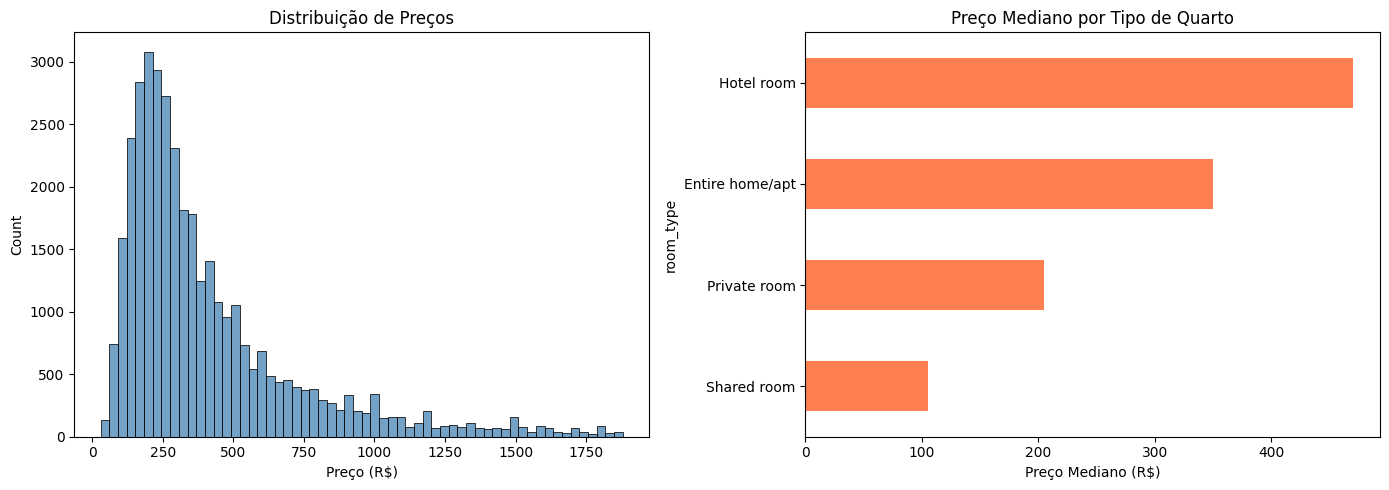

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição de preços
df_sem_outlier = df[df['price'] < df['price'].quantile(0.95)]
sns.histplot(df_sem_outlier['price'], bins=60, ax=axes1[0], color='steelblue')
axes1[0].set_title('Distribuição de Preços')
axes1[0].set_xlabel('Preço (R$)')

# 2. Preço médio por tipo de quarto
medias = df.groupby('room_type')['price'].median().sort_values()
medias.plot(kind='barh', ax=axes1[1], color='coral')
axes1[1].set_title('Preço Mediano por Tipo de Quarto')
axes1[1].set_xlabel('Preço Mediano (R$)')

plt.tight_layout()
plt.show() 

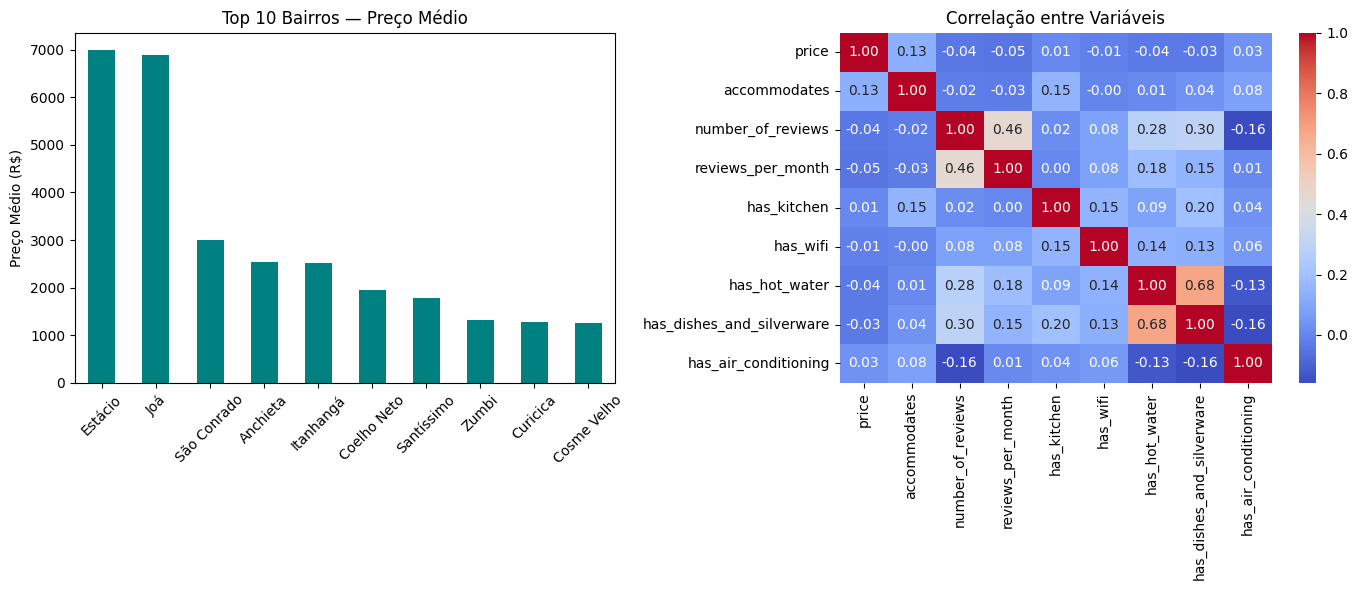

In [302]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# 3. Top 10 bairros mais caros
top_bairros = df.groupby('neighbourhood_cleansed')['price'].mean().nlargest(10)
top_bairros.plot(kind='bar', ax=axes2[0], color='teal')
axes2[0].set_title('Top 10 Bairros — Preço Médio')
axes2[0].tick_params(axis='x', rotation=45)
axes2[0].set_ylabel('Preço Médio (R$)')
axes2[0].set_xlabel('')

# 4. Correlação entre Variáveis
cols_corr = ['price', 'accommodates', 'number_of_reviews', 'reviews_per_month'] + colunas_novas
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes2[1])
axes2[1].set_title('Correlação entre Variáveis')

plt.tight_layout()
plt.show()

In [303]:
df_estacio = df[df['neighbourhood_cleansed'] == 'Estácio']

media_estacio = df_estacio['price'].mean()
mediana_estacio = df_estacio['price'].median()

moda_estacio = df_estacio['price'].mode()[0] 

print(f"--- Valores de Preço no Bairro Estácio ---")
print(f"Média (Average): R$ {media_estacio:.2f}")
print(f"Mediana (Valor do meio): R$ {mediana_estacio:.2f}")
print(f"Moda (Preço mais comum): R$ {moda_estacio:.2f}")

anuncios_caros = df_estacio.sort_values(by='price', ascending=False)

display(anuncios_caros[['id', 'name', 'room_type', 'price']].head(5))

--- Valores de Preço no Bairro Estácio ---
Média (Average): R$ 7003.15
Mediana (Valor do meio): R$ 160.00
Moda (Preço mais comum): R$ 160.00


,id,name,room_type,price
7624,30033272,Apartamento em Rio de Janeiro,Entire home/apt,500000.0
23551,1071216377896851973,"Apt arejado, sol da manhã",Private room,1485.0
33742,1338558066930251191,Em frente ao metrô,Entire home/apt,972.0
37042,1389833350160373079,Hospedagem Santo Antônio,Private room,900.0
35733,1363181864923328390,quarto para casal,Private room,765.0


### Gráfico 1 - Distribuição de preços: 
A distribuição de preços é assimétrica à direita, com a maioria dos anúncios concentrada entre R$100 e R$500. O pico está  em torno de R$200-R$300, indicando que esse é o preço mais comum no mercado. A cauda longa à direita mostra a existência de imóveis de luxo que elevam a média, justificando o uso da mediana como medida mais representativa. (Caso utilize a média, a conta seria altamente influneciada)

### Gráfico 2 — Preço Mediano por Tipo de Quarto:
Hotel room apresenta o maior preço mediano (~R$450), seguido de Entire home/apt (R$350). Private room (R$200) e Shared room (R$100) são significativamente mais baratos. Isso reflete a lógica do mercado: acomodações completas e com serviços agregados comandam preços maiores, enquanto quartos compartilhados atendem um público mais sensível ao preço.

### Gráfico 3 — Top 10 Bairros por Preço Médio:
Estácio e Joá lideram com preços médios próximos a R$7.000, valores muito acima dos demais bairros. Joá e estácio lideram o ranking, Joá lidera devido ao seu luxo, porém Estácio é um bairro popular, o que mostra umas das falhas da média, existe um imóvel com uma diária no valor de 500.000, o que distorce completamente o grafico.São Conrado, Anchieta e Itanhangá completam o top 5, todos com características de bairros mais exclusivos do Rio.

### Gráfico 4 — Heatmap de Correlação
As correlações mais relevantes são:
- `has_hot_water` e `has_dishes_and_silverware` (0.68): amenidades que 
  tendem a aparecer juntas em imóveis mais equipados.
- `price` tem correlações fracas com todas as variáveis, indicando que 
  o preço é influenciado por fatores não capturados diretamente nessas 
  colunas, como localização e qualidade do imóvel.
- `has_air_conditioning` apresenta correlação negativa fraca com reviews, 
  possivelmente por ser menos comum em imóveis mais simples e populares.


In [304]:
from scipy import stats

# --- Teste 1: Amenidade (WiFi afeta número de reviews?) ---
# H0: número de reviews é igual com ou sem WiFi
# H1: anúncios com WiFi têm mais reviews

com_wifi = df[df['has_wifi'] == 1]['number_of_reviews']
sem_wifi = df[df['has_wifi'] == 0]['number_of_reviews']

stat, p = stats.mannwhitneyu(com_wifi, sem_wifi, alternative='greater')

print(f"--- Teste 1: Impacto do Wi-Fi na Demanda ---")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Conclusão: A diferença é REAL e comprovada!")
    print("Imóveis com Wi-Fi recebem significativamente mais avaliações (têm mais giro de hóspedes).")
else:
    print("Conclusão: NÃO existe diferença comprovada.")
    print("Ter Wi-Fi não garantiu mais avaliações neste cenário. Qualquer diferença vista é pura coincidência.")

--- Teste 1: Impacto do Wi-Fi na Demanda ---
p-valor: 0.0000
Conclusão: A diferença é REAL e comprovada!
Imóveis com Wi-Fi recebem significativamente mais avaliações (têm mais giro de hóspedes).


In [305]:
# --- Teste 2: Bairros têm preços diferentes? ---
# H0: preço médio é igual entre os bairros
# H1: pelo menos um bairro tem preço diferente

# Agrupando apenas bairros com um volume bom de anúncios (mais de 30)
grupos_bairros = [g['price'].values for _, g in df.groupby('neighbourhood_cleansed') if len(g) >= 30]

# Calculando a estatística
stat, p = stats.kruskal(*grupos_bairros)

print(f"\n--- Teste 2: Impacto da Localização no Preço ---")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Conclusão: O bairro afeta fortemente o valor da diária!")
    print("Existe uma diferença de preços real e estatisticamente comprovada entre as diferentes regiões.")
else:
    print("Conclusão: NÃO existe diferença de preço comprovada entre os bairros.")
    print("Estatisticamente, os anfitriões cobram valores parecidos independente da região analisada.")


--- Teste 2: Impacto da Localização no Preço ---
p-valor: 0.0000
Conclusão: O bairro afeta fortemente o valor da diária!
Existe uma diferença de preços real e estatisticamente comprovada entre as diferentes regiões.


In [306]:
from scipy import stats

# --- Teste 3 ---
# Pergunta: Superhosts investem mais em Ar Condicionado do que anfitriões comuns?
# H0: Não existe relação
# H1: Existe relação

tabela = pd.crosstab(df['host_is_superhost'], df['has_air_conditioning'])
print("--- Tabela Cruzada (Contagem) ---")
print(tabela)
print("-" * 30)
stat, p, dof, expected = stats.chi2_contingency(tabela)

print(f"Teste 3 (Qui-Quadrado) | p-valor: {p:.4f}")
if p < 0.05:
    print("Conclusão: A relação é REAL e comprovada estatisticamente!")
    print("Anfitriões Superhost realmente têm um comportamento diferente e investem mais em Ar Condicionado.")
else:
    print("Conclusão: NÃO existe relação comprovada.")
    print("Qualquer diferença entre Superhosts e anfitriões comuns é puro acaso (coincidência).")

--- Tabela Cruzada (Contagem) ---
has_air_conditioning     0      1
host_is_superhost                
f                     7965  15745
t                     5705   7968
------------------------------
Teste 3 (Qui-Quadrado) | p-valor: 0.0000
Conclusão: A relação é REAL e comprovada estatisticamente!
Anfitriões Superhost realmente têm um comportamento diferente e investem mais em Ar Condicionado.


In [307]:
# Criando as 5 colunas binárias 
df['has_wifi'] = df['amenities'].str.contains('Wifi|Wi-Fi', case=False, na=False).astype(int)
df['has_air_cond'] = df['amenities'].str.contains('Air conditioning', case=False, na=False).astype(int)
df['has_kitchen'] = df['amenities'].str.contains('Kitchen', case=False, na=False).astype(int)
df['has_tv'] = df['amenities'].str.contains('TV', case=False, na=False).astype(int)
df['has_pool'] = df['amenities'].str.contains('Pool', case=False, na=False).astype(int)

resumo_host = df.groupby('host_is_superhost').agg(
    total_anuncios=('id', 'count'),
    preco_mediano=('price', 'median'), 
    reviews_medio=('number_of_reviews', 'mean'),
    
    perc_wifi=('has_wifi', 'mean'),
    perc_ar_cond=('has_air_cond', 'mean'),
    perc_cozinha=('has_kitchen', 'mean'),
    perc_tv=('has_tv', 'mean'),
    perc_piscina=('has_pool', 'mean')
)

colunas_perc = ['perc_wifi', 'perc_ar_cond', 'perc_cozinha', 'perc_tv', 'perc_piscina']
resumo_host[colunas_perc] = (resumo_host[colunas_perc] * 100).round(1)
resumo_host['preco_mediano'] = resumo_host['preco_mediano'].round(2)
resumo_host['reviews_medio'] = resumo_host['reviews_medio'].round(1)

display(resumo_host)

,total_anuncios,preco_mediano,reviews_medio,perc_wifi,perc_ar_cond,perc_cozinha,perc_tv,perc_piscina
host_is_superhost,,,,,,,,
f,23710,349.0,14.1,94.5,66.4,90.8,88.1,24.8
t,13673,283.0,49.6,98.8,58.3,92.5,92.7,22.2
